#  MuJoCo Bootcamp : Jacobian and Inverse Kinematics

---- 

- conda env : [ai_robotics](../../../README.md#setup-a-conda-environment)

---

### Reference : 
- https://pab47.github.io/mujoco.html
- https://youtu.be/ZspzVxFAreQ

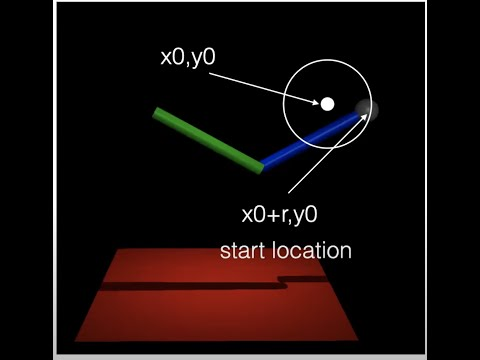

In [6]:
from IPython.display import YouTubeVideo

YouTubeVideo('ZspzVxFAreQ')

## Run python code

In [ ]:
!python doublependulum_ik.py 

## Jupyter code

### Load XML file and build model and data

In [1]:
import mujoco as mj
import numpy as np
import mediapy as media
from numpy.linalg import inv

# Create an XML file string for a simple ball on a plane
xml_path = "./doublependulum.xml" 

# MuJoCo data structures
model = mj.MjModel.from_xml_path(xml_path)
data = mj.MjData(model)

### Setup the controller

In [2]:
r = 0.5

def controller(model, data):
    """
    This function implements a P controller for tracking
    the reference motion.
    """
    # End-effector position
    end_eff_pos = data.sensordata[:3]

    # Compute end-effector Jacobian
    jacp = np.zeros((3, 2))
    mj.mj_jac(model, data, jacp, None, end_eff_pos, 2)

    # Δq = Jinv * Δx
    J = jacp[[0, 2], :]
    dx = np.array([
        [x_0 + r * np.cos(data.time) - data.sensordata[0]],
        [z_0 + r * np.sin(data.time) - data.sensordata[2]]
    ])
    dq = inv(J) @ dx

    # Target position is q + Δq
    data.ctrl[0] = data.qpos[0] + dq[0, 0]
    data.ctrl[2] = data.qpos[1] + dq[1, 0]

#use forward kinematics to set the position
mj.mj_forward(model, data)

## center of drawn circle
x_0 = data.sensordata[0] - r
z_0 = data.sensordata[2]

#set the controller
mj.set_mjcb_control(controller)

### Setup the configuration of render

In [3]:
# Offscreen rendering setup
width, height = 200, 200
renderer = mj.Renderer(model, width, height)

# Set camera configuration
cam = mj.MjvCamera()                        # Abstract camera
opt = mj.MjvOption()                        # visualization options
mj.mjv_defaultCamera(cam)
mj.mjv_defaultOption(opt)
# Set camera configuration
cam.azimuth = 89.608063
cam.elevation = -11.588379
cam.distance = 5.0
cam.lookat = np.array([0.0, 0.0, 1.5])

### Initialization 

In [4]:
# Reset the data to initial state
mj.mj_resetData(model, data)

# Set initial angle of pendulum
data.qpos[0] = -0.5
data.qpos[1] = 1.0

### Simulation

In [5]:
# Store frames for visualization
frames = []
framerate = 60
simend = 5

while data.time < simend:
    simstart = data.time
    # Perform a single simulation step
    while (data.time - simstart < 1.0/60.0):
        mj.mj_step(model, data)
    
    # Render the scene from the specified camera
    renderer.update_scene(data, camera=cam)
    
    # Get the rendered RGB image and store it
    rgb_image = renderer.render()
    frames.append(rgb_image)

media.show_video(frames, fps=framerate)




This browser does not support the video tag.
